In [1]:
import pandas as pd
import numpy as np

In [2]:
df=pd.read_csv(r'C:\FBS\Data Analysis\classification\Default.csv')

In [3]:
df.head()


,default,student,balance,income
0,No,No,729.526495,44361.62507
1,No,Yes,817.180407,12106.13470
2,No,No,1073.549164,31767.13895
3,No,No,529.250605,35704.49394
4,No,No,785.655883,38463.49588


In [4]:
df.default.unique()

<StringArray>
['No', 'Yes']
Length: 2, dtype: str

In [5]:
df.default.value_counts() #data is imbalanced more no values than yes values

default
No     9667
Yes     333
Name: count, dtype: int64

In [6]:
df.describe()

,balance,income
count,10000.000000,10000.000000
mean,835.374886,33516.981876
std,483.714985,13336.639563
min,0.000000,771.967729
25%,481.731105,21340.462905
50%,823.636973,34552.644800
75%,1166.308387,43807.729275
max,2654.322576,73554.233500


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   default  10000 non-null  str    
 1   student  10000 non-null  str    
 2   balance  10000 non-null  float64
 3   income   10000 non-null  float64
dtypes: float64(2), str(2)
memory usage: 312.6 KB


In [8]:
df.isna().sum()

default    0
student    0
balance    0
income     0
dtype: int64

In [9]:
df.head()

,default,student,balance,income
0,No,No,729.526495,44361.62507
1,No,Yes,817.180407,12106.13470
2,No,No,1073.549164,31767.13895
3,No,No,529.250605,35704.49394
4,No,No,785.655883,38463.49588


In [10]:
# balance and income need to normalised and student we need to apply one hot encoding

In [11]:
df_student=pd.get_dummies(df.student,drop_first=True,dtype=int)
df_student

,Yes
0,0
1,1
2,0
3,0
4,0
...,...
9995,0
9996,0
9997,0
9998,0


In [12]:
#remove student clumn from our dataframe
df.drop('student',axis=1,inplace=True)
df=pd.concat([df,df_student],axis=1)
df.head()

,default,balance,income,Yes
0,No,729.526495,44361.62507,0
1,No,817.180407,12106.13470,1
2,No,1073.549164,31767.13895,0
3,No,529.250605,35704.49394,0
4,No,785.655883,38463.49588,0


In [13]:
#normalization
from sklearn.preprocessing import MinMaxScaler

In [14]:
min_max=MinMaxScaler()
df_normalised=min_max.fit_transform(df[['balance','income']])
df_normalised=pd.DataFrame(df_normalised,columns=['balance','income'])

In [15]:
df_normalised.head()

,balance,income
0,0.274845,0.598905
1,0.307868,0.155727
2,0.404453,0.425862
3,0.199392,0.479959
4,0.295991,0.517867


In [16]:
df.drop(['balance','income'],axis=1,inplace=True)
df.head()

,default,Yes
0,No,0
1,No,1
2,No,0
3,No,0
4,No,0


In [17]:
df=pd.concat([df,df_normalised],axis=1)

In [18]:
df.head()

,default,Yes,balance,income
0,No,0,0.274845,0.598905
1,No,1,0.307868,0.155727
2,No,0,0.404453,0.425862
3,No,0,0.199392,0.479959
4,No,0,0.295991,0.517867


In [19]:
x=df.drop('default',axis=1)
y=df.default

In [20]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [21]:
from sklearn.neighbors import KNeighborsClassifier

In [22]:
from sklearn.metrics import accuracy_score

In [23]:
knn=KNeighborsClassifier(n_neighbors=5)
knn.fit(x_train,y_train)
y_pred=knn.predict(x_train)
accuracy_score(y_train,y_pred)

0.97575

In [24]:
# decession Tree model

In [25]:
from sklearn.tree import DecisionTreeClassifier

In [26]:
tree=DecisionTreeClassifier(max_depth=4,criterion='gini') #()
tree.fit(x_train,y_train)
y_pred=tree.predict(x_train)
accuracy_score(y_train,y_pred)

0.975875

In [27]:
from sklearn.tree import  plot_tree
import matplotlib.pyplot as plt


[Text(0.5, 0.9, 'balance <= 0.677\ngini = 0.064\nsamples = 8000\nvalue = [7736, 264]'),
 Text(0.25, 0.7, 'balance <= 0.56\ngini = 0.032\nsamples = 7766\nvalue = [7638, 128]'),
 Text(0.375, 0.8, 'True  '),
 Text(0.125, 0.5, 'balance <= 0.482\ngini = 0.013\nsamples = 7229\nvalue = [7181, 48]'),
 Text(0.0625, 0.3, 'balance <= 0.361\ngini = 0.006\nsamples = 6535\nvalue = [6515, 20]'),
 Text(0.03125, 0.1, 'gini = 0.001\nsamples = 4859\nvalue = [4856, 3]'),
 Text(0.09375, 0.1, 'gini = 0.02\nsamples = 1676\nvalue = [1659, 17]'),
 Text(0.1875, 0.3, 'balance <= 0.482\ngini = 0.077\nsamples = 694\nvalue = [666, 28]'),
 Text(0.15625, 0.1, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.21875, 0.1, 'gini = 0.075\nsamples = 693\nvalue = [666, 27]'),
 Text(0.375, 0.5, 'balance <= 0.641\ngini = 0.254\nsamples = 537\nvalue = [457, 80]'),
 Text(0.3125, 0.3, 'balance <= 0.561\ngini = 0.214\nsamples = 410\nvalue = [360, 50]'),
 Text(0.28125, 0.1, 'gini = 0.48\nsamples = 5\nvalue = [2, 3]'),
 Text(0.3

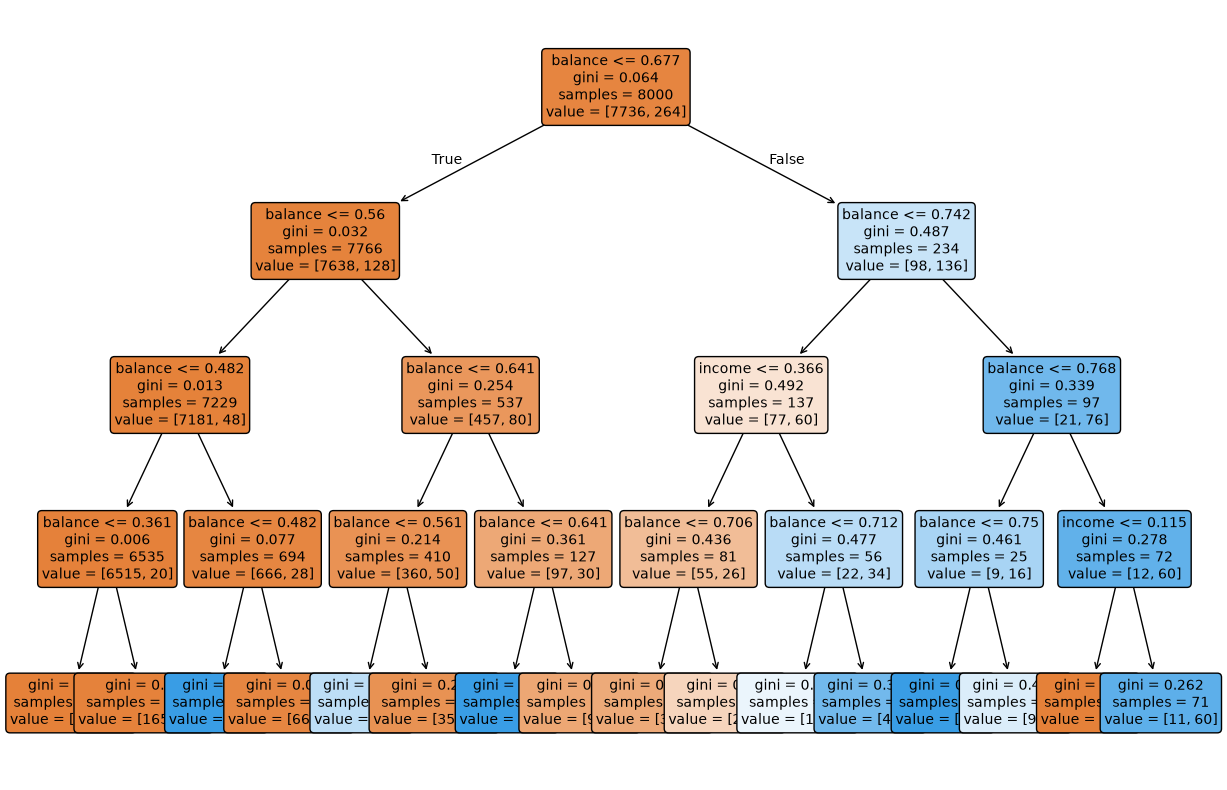

In [28]:
plt.figure(figsize=(15,10))
plot_tree(
    tree,
    feature_names=x.columns,
    filled=True,
    rounded=True,
    fontsize=10
)

In [29]:
import matplotlib.pyplot as plt

<Axes: xlabel='balance', ylabel='default'>

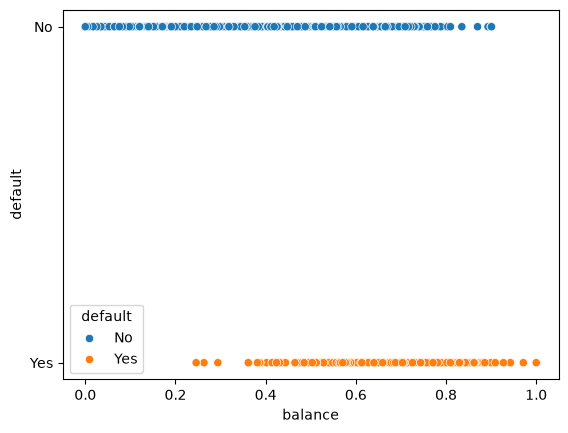

In [30]:
import seaborn as sns
sns.scatterplot(x='balance',y='default',data=df,hue='default')

In [31]:
#logistic regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [32]:
model=LogisticRegression()
model.fit(x_train,y_train)
y_pred=model.predict(x_test)
accuracy_score(y_test,y_pred)

0.9675

In [34]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [35]:
#support vector machine
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

In [36]:
linear_svm=SVC(kernel='linear')
linear_svm.fit(x_train,y_train)
linear_svm.score(x_test,y_test)

0.9655

In [37]:
!pip install mlxtend

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 24.3.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip
